In [185]:
import torch
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.image as mpimg

plt.rcParams['font.family'] = 'Times New Roman'
letter_size=36

## Read in data

In [15]:
escape_date = '2025-02-07'
sb = .01

escape_results = torch.load(f'model_covdb/results.{escape_date}.sb{sb}.pt')
escape_traces = escape_results['traces']
escape_data = escape_results['data']

escape_ranges = escape_traces['β_ω'].mean(dim=0).max(dim=0).values - escape_traces['β_ω'].mean(dim=0).min(dim=0).values

In [28]:
earliest_date = {  # PULLED FROM GISAID (seen 10 times)
    'Alpha': '2020-01-19' ,   # how is Alpha being seen before B.1 (widltype)...?
    'B.1': '2020-01-28' ,
    'BA.1': '2020-11-23' ,
    # 'BA.2': '2020-07-04' ,   # how is BA.2 being seen before BA.1...?
    # 'BA.5/7': '2020-07-21' ,
    'Beta': '2020-06-04' ,
    'Delta': '2020-05-01' ,
    # 'Epsilon': '2020-07-15' ,
    # 'Gamma': '2020-08-07' ,
    # 'Iota': '2020-12-02' ,
    # 'L452R': '2020-03-17' ,
    # 'Lambda': '2021-01-08' ,
    # 'Mu': '2021-02-21' ,
    'Omicron BA.4/5': '2020-07-04' ,
    'BA.2.12.1':''
    # 'WT': '2020-01-01', #None ,
    # 'pan-SARS-CoV-2': None ,
    # 'unknown': None
}

# Convert to DataFrame for sorting
earliest_date = pd.DataFrame(list(earliest_date.items()), columns=['Pool', 'First seen date'])
earliest_date['First seen date'] = pd.to_datetime(earliest_date['First seen date'])  
earliest_date = earliest_date.sort_values('First seen date')

# Create a color palette
colormap = dict(zip(earliest_date['Pool'], sns.color_palette("nipy_spectral", len(earliest_date))))
gray = (0.5, 0.5, 0.5)
# colormap['WT'] = gray
colormap['pan-SARS-CoV-2'] = gray
colormap['unknown'] = gray

# Create sort key
sortkey = earliest_date.sort_values(by='First seen date').reset_index(drop=True).reset_index()

In [146]:
mutation_pool_effects = pd.DataFrame(columns=escape_data['features'], index=escape_data['pools_map'], data=escape_traces['β_ω'].mean(dim=0)
                                    ).reset_index(
                                    ).melt(id_vars='index', value_vars=None, var_name='Mutation', value_name='Effect'
                                    ).rename(columns={'index':'Pool'})
# mutation_effects_range = pool_effects[['Mutation', 'Effect']].groupby('Mutation').agg(lambda x: x.max() - x.min()).reset_index().rename(columns={'Effect':'Effect range'})

In [29]:
# Calculate the avg pool specific effect
pool_specific_effects = escape_traces['β_ω'].mean(dim=0)
pool_agnostic_effects = escape_traces['β'].mean(dim=0)
pool_effect_differences = pool_specific_effects - pool_agnostic_effects

pool_effect_differences_df = pd.DataFrame(index=escape_data['pools_map'],
                                          columns=escape_data['features'],
                                          data=pool_effect_differences
                                   ).reset_index(
                                   ).melt(id_vars='index', 
                                          var_name='Mutation', 
                                          value_name='Effect difference'
                                  ).rename(columns={'index':'Pool'})
sorted_pool_effect_differences_df = pool_effect_differences_df.sort_values(by='Pool', key=lambda x: x.map({p:i for p, i in zip(sortkey['Pool'], sortkey['index'])}))


In [ ]:
# Calculate moving average of relative pool escape
pool_effect_differences_df_withpos = sorted_pool_effect_differences_df
pool_effect_differences_df_withpos['Position'] = pool_effect_differences_df_withpos['Mutation'].apply(lambda x: int(''.join(filter(str.isdigit, x))))
avg_pool_difference_by_pos = pool_effect_differences_df_withpos[['Pool', 'Position', 'Effect difference']
                                                      ].groupby(['Pool', 'Position']
                                                      ).agg('mean'
                                                      ).reset_index(
                                                      ).sort_values(by=['Position', 'Pool']
                                                      ).reset_index(drop=True);

window_size=100
avg_pool_difference_by_pos['Moving avg'] = avg_pool_difference_by_pos.groupby('Pool', group_keys=False, sort=False)['Effect difference'] \
                                                                      .apply(lambda x: x.rolling(window=window_size, center=True, min_periods=1).mean())

## Plot

In [3]:
# Manhattan plot
def setup(ax, ylim):
    options= dict()
    options['xlim'] = [0, 1273]
    options['ylim'] = ylim #[-1, 1]
    
    ax.set_xlim(options['xlim'])
    ax.set_ylim(options['ylim'])
    
    ax.set_ylabel('Mutation effect')
    ax.set_xlabel('Spike AA Position')

    return options

def get_positions(mutations):
    coefficients = mutations.copy()
    
    positions = [int(''.join(filter(str.isdigit, c))) for c in coefficients] #[int(c[1:-1]) for c in coefficients]
    return positions, coefficients

def plot_coef(ax, effects, positions, mutations, options):
    ax.plot(positions, effects, 'ro')
    
    texts = []
    for i, (pos, fea) in enumerate(zip(positions, mutations)):
        x = pos
        y = effects[i]
        text = fea #+ '\n' + '{:1.2f}'.format(y)
        texts.append(ax.annotate(text, xy=(x, y), xytext=(x, y), fontsize=8))

    # adjust_text(texts);
    
    ax.set_xlim(options['xlim'])
    
def plot_regions(ax, options):
    regions = {'NTD':[13,304],
               'RBD':[417,505],
               '':[438, 508], # RBM
               'FCS':[672,709],
               'FP':[788, 806],
               'IFP':[816, 833],
               'HR1':[918,983],
               'HR2':[1162,1203]}
    
    for r in regions:
        ax.vlines(regions[r], options['ylim'][0], options['ylim'][1], linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
        ax.fill_between(regions[r], options['ylim'][0], options['ylim'][1], color='tab:blue', alpha=0.1)
        ax.text(np.mean(regions[r]), options['ylim'][1]*0.95, r, ha='center', va='top', fontsize=7)

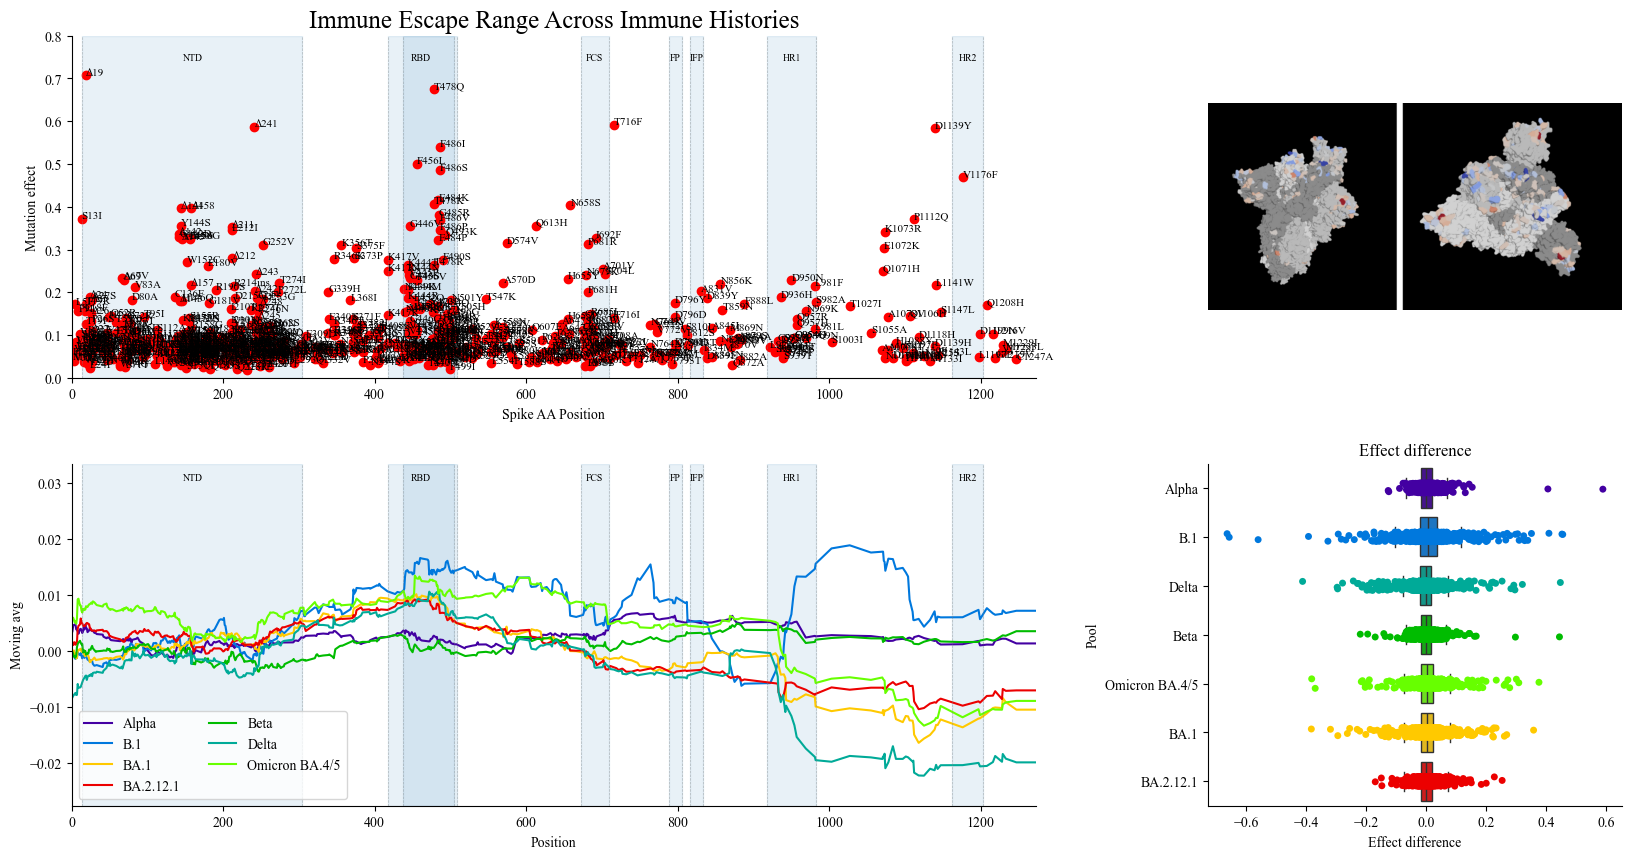

In [127]:
fig, axes = plt.subplots(2,3, figsize=(20,10), gridspec_kw={'width_ratios':[7,2,2]})

ax = axes[0,0]
options = setup(ax, [0, 0.8])
positions, mutations = get_positions(escape_data['features'])
plot_coef(ax, escape_ranges, positions, mutations, options)
plot_regions(ax, options)
ax.set_title('Immune Escape Range Across Immune Histories', fontsize=18);
ax.spines[['top', 'right']].set_visible(False);

ax = axes[0,1]
img = mpimg.imread('figs/escape_struct_temp.png')
ax.imshow(img)
ax.axis('off');

ax = axes[1,0]
sns.lineplot(x='Position',
             y='Moving avg',
             hue='Pool',
             # fill=True,
             palette=colormap,
             data=avg_pool_difference_by_pos,
             ax=ax)
ax.set_xlim([0, 1273]);
ylim = ax.get_ylim()
plot_regions(ax, {'ylim':ylim})
ax.set_ylim(ylim)
ax.legend(loc='lower left', ncol=2)
ax.spines[['top', 'right']].set_visible(False);


ax = axes[1,1]
ax.set_title('Effect difference')
sns.boxplot(y='Pool',
            x='Effect difference',
            hue='Pool',
            palette=colormap,
            data=sorted_pool_effect_differences_df,
            showfliers=False,
            ax=ax)
sns.stripplot(y='Pool',
              x='Effect difference',
              hue='Pool',
              palette=colormap,
              data=sorted_pool_effect_differences_df,
              jitter=True,
              ax=ax);
ax.spines[['top', 'right']].set_visible(False);

# fig.tight_layout();
fig.subplots_adjust(hspace=0.25, wspace=0.25);
# fig.savefig(f'figs/covdb/Manhattan_{date}.png', dpi=150)

/var/folders/lj/kt2p_lkd6rbg0tlbf4ykgqrm0000gq/T/ipykernel_99897/4141568968.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([l if len(l.get_text())<10 else '' for l in ax.get_yticklabels()]);


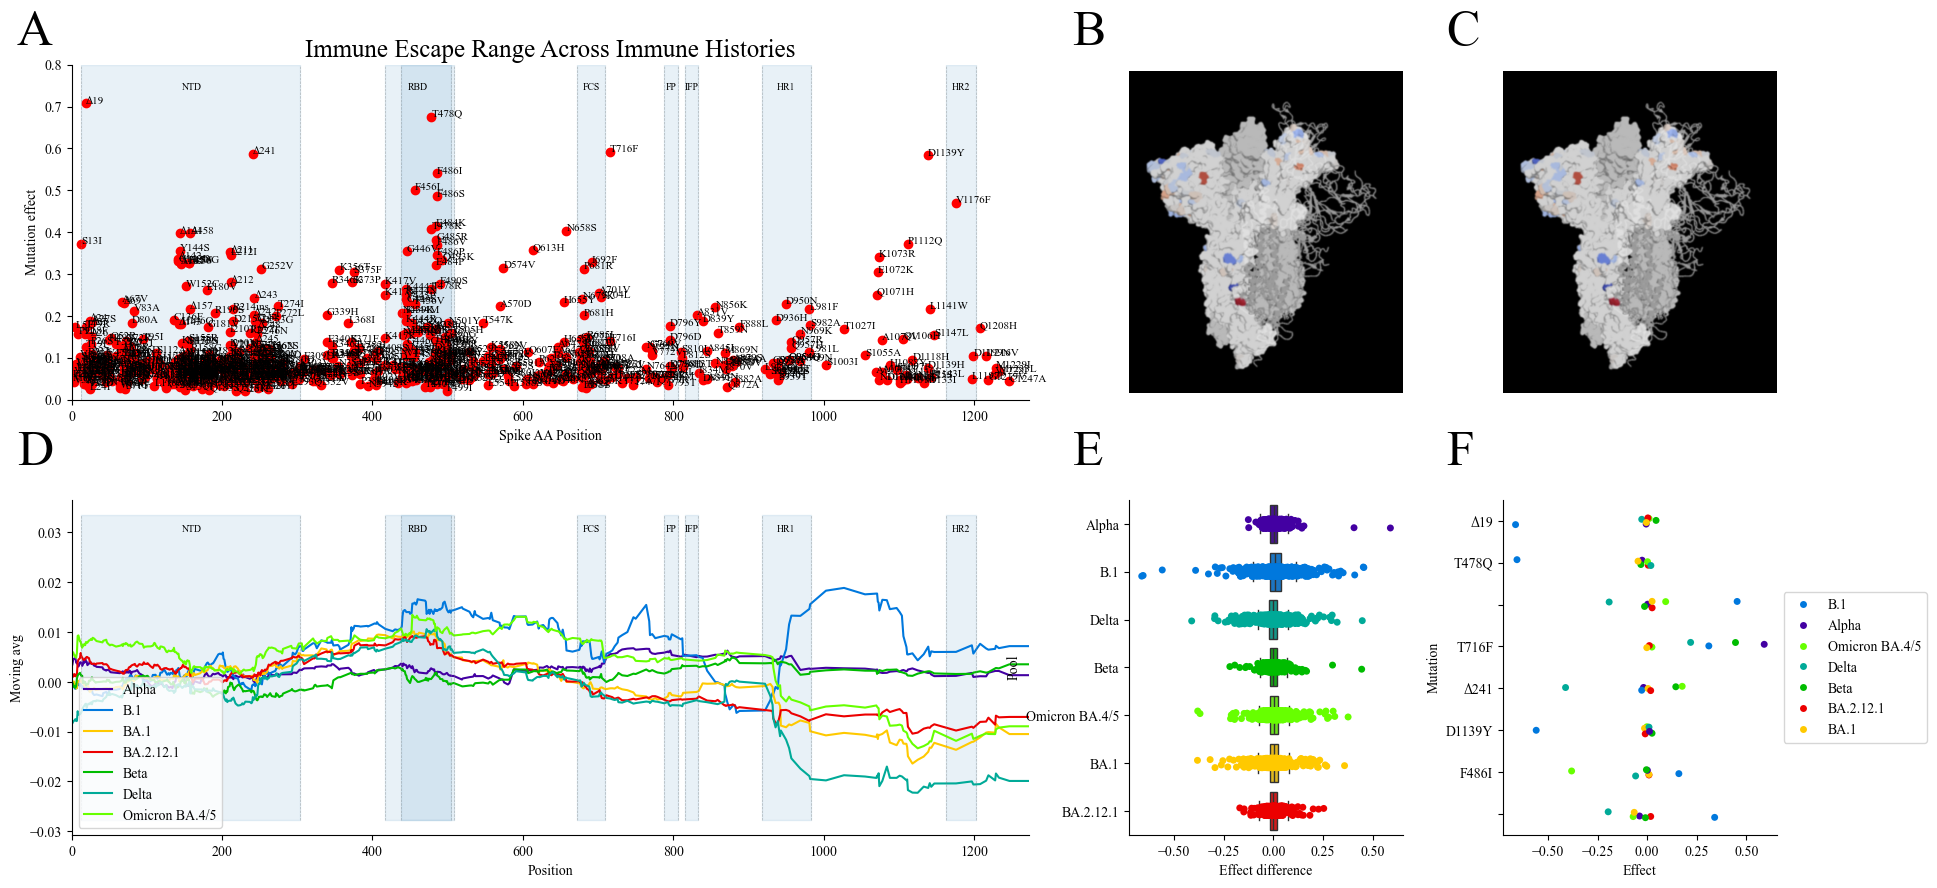

In [194]:
fig = plt.figure(figsize=(22,10))
gs = gridspec.GridSpec(2, 3, figure=fig, width_ratios=[7, 2, 2])

ax = fig.add_subplot(gs[0, 0])
fig.text(0.1, 0.9, 'A', fontsize=letter_size)
options = setup(ax, [0, 0.8])
positions, mutations = get_positions(escape_data['features'])
plot_coef(ax, escape_ranges, positions, mutations, options)
plot_regions(ax, options)
ax.set_title('Immune Escape Range Across Immune Histories', fontsize=18);
ax.spines[['top', 'right']].set_visible(False);


ax = fig.add_subplot(gs[0, 1])
fig.text(0.58, 0.9, 'B', fontsize=letter_size)
img = mpimg.imread('figs/infectivity_struct_temp.png')
ax.imshow(img)
ax.axis('off');


ax = fig.add_subplot(gs[0, 2])
fig.text(0.75, 0.9, 'C', fontsize=letter_size)
img = mpimg.imread('figs/infectivity_struct_temp.png')
ax.imshow(img)
ax.axis('off');


ax = fig.add_subplot(gs[1, 0])
fig.text(0.1, 0.48, 'D', fontsize=letter_size)
sns.lineplot(x='Position',
             y='Moving avg',
             hue='Pool',
             # fill=True,
             palette=colormap,
             data=avg_pool_difference_by_pos,
             ax=ax)
ax.set_xlim([0, 1273]);
plot_regions(ax, {'ylim':ax.get_ylim()})
ax.legend(loc='lower left')
ax.spines[['top', 'right']].set_visible(False);


ax = fig.add_subplot(gs[1, 1])
fig.text(0.58, 0.48, 'E', fontsize=letter_size)
sns.boxplot(y='Pool',
            x='Effect difference',
            hue='Pool',
            palette=colormap,
            data=sorted_pool_effect_differences_df,
            showfliers=False,
            ax=ax)
sns.stripplot(y='Pool',
              x='Effect difference',
              hue='Pool',
              palette=colormap,
              data=sorted_pool_effect_differences_df,
              jitter=True,
              ax=ax);
ax.spines[['top', 'right']].set_visible(False);


ax = fig.add_subplot(gs[1, 2])
fig.text(0.75, 0.48, 'F', fontsize=letter_size)
top_n = 8
sns.stripplot(x='Effect',
              y='Mutation',
              hue='Pool',
              palette=colormap,
              data=pd.merge(mutation_pool_effects,
                            pd.DataFrame({'Mutation':escape_data['features'], 'Effect range':escape_ranges}).sort_values(by='Effect range', ascending=False).head(top_n),
                            on='Mutation'
                           ).sort_values(by='Effect range', ascending=False),
              ax=ax)
ax.spines[['top', 'right']].set_visible(False);
ax.set_yticklabels([l if len(l.get_text())<10 else '' for l in ax.get_yticklabels()]);
ax.legend(bbox_to_anchor=(1, 0.5), loc='center left');

fig.subplots_adjust(hspace=0.3);

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


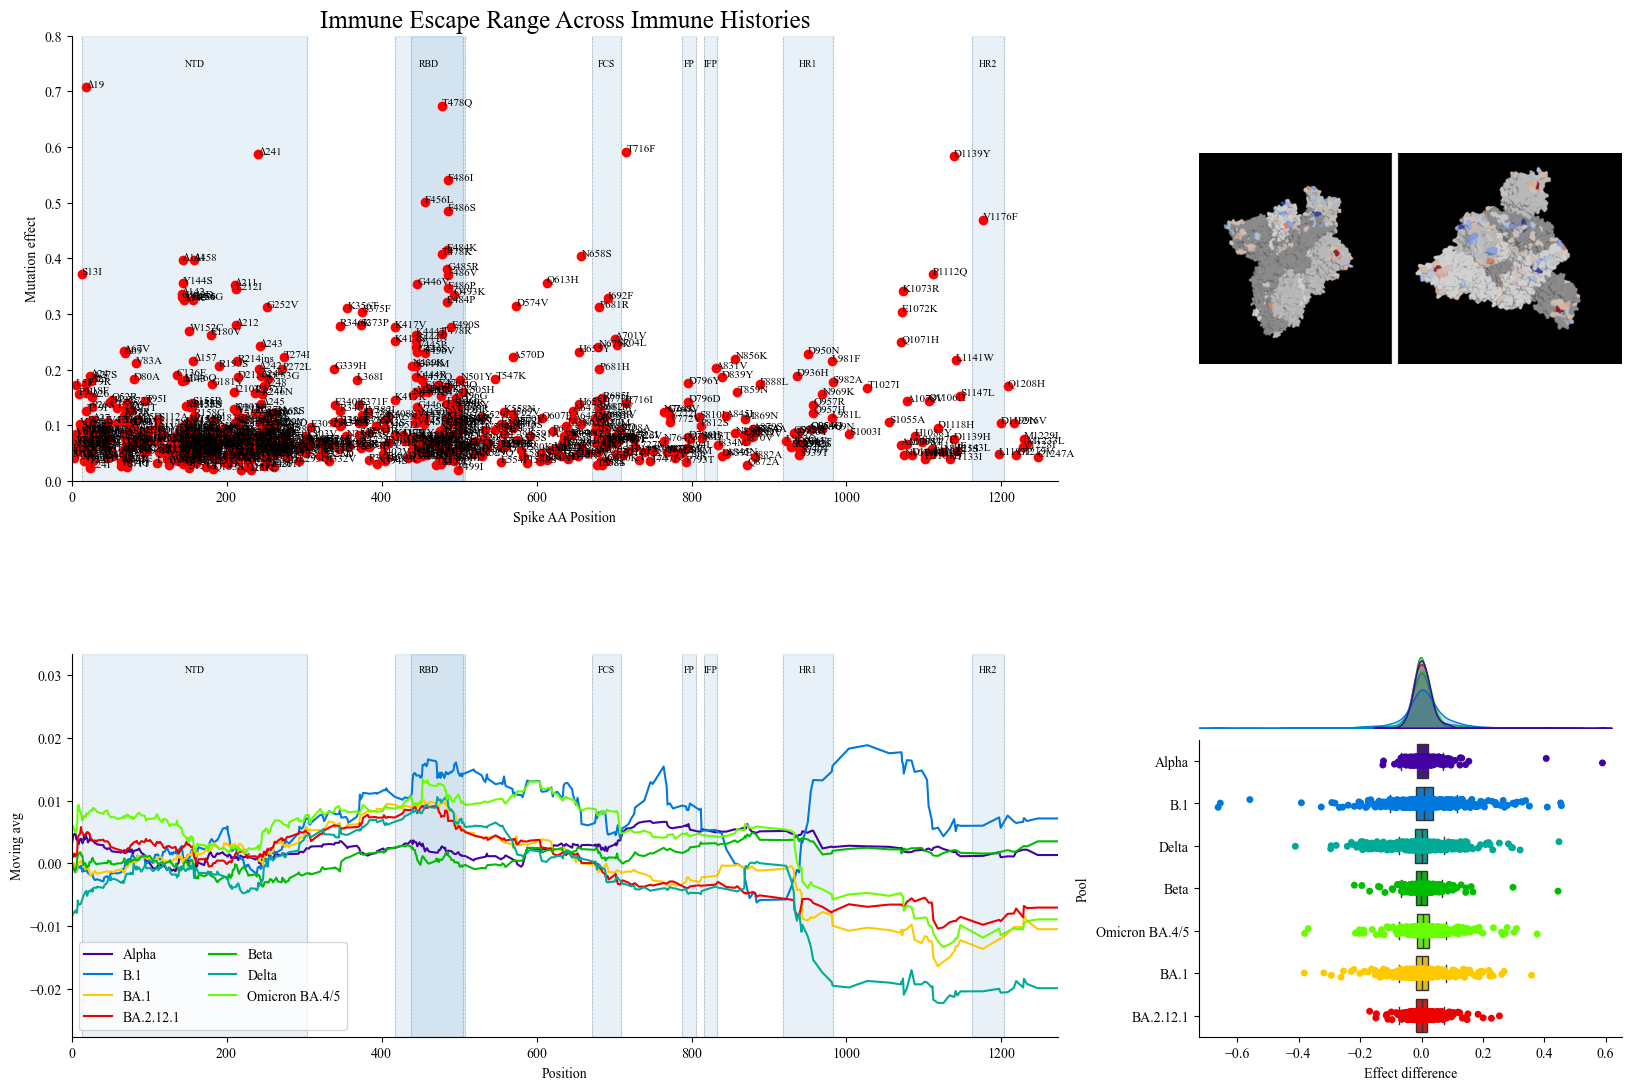

In [119]:
fig = plt.figure(figsize=(20,13))
gs = gridspec.GridSpec(4, 2, figure=fig, width_ratios=[7, 3], height_ratios=[3, 1, 0.5, 2])

ax = fig.add_subplot(gs[0, 0])
options = setup(ax, [0, 0.8])
positions, mutations = get_positions(escape_data['features'])
plot_coef(ax, escape_ranges, positions, mutations, options)
plot_regions(ax, options)
ax.set_title('Immune Escape Range Across Immune Histories', fontsize=18);
ax.spines[['top', 'right']].set_visible(False);

ax = fig.add_subplot(gs[0, 1])
img = mpimg.imread('figs/escape_struct_temp.png')
ax.imshow(img)
ax.axis('off');

ax = fig.add_subplot(gs[2:4, 0])
sns.lineplot(x='Position',
             y='Moving avg',
             hue='Pool',
             # fill=True,
             palette=colormap,
             data=avg_pool_difference_by_pos,
             ax=ax)
ax.set_xlim([0, 1273]);
plot_regions(ax, {'ylim':ax.get_ylim()})
ax.legend(loc='lower left')
ax.spines[['top', 'right']].set_visible(False);

ax = fig.add_subplot(gs[3, 1])
sns.boxplot(y='Pool',
            x='Effect difference',
            hue='Pool',
            palette=colormap,
            data=sorted_pool_effect_differences_df,
            showfliers=False,
            ax=ax)
sns.stripplot(y='Pool',
              x='Effect difference',
              hue='Pool',
              palette=colormap,
              data=sorted_pool_effect_differences_df,
              jitter=True,
              ax=ax);
ax.spines[['top', 'right']].set_visible(False);
xlim = ax.get_xlim()

ax = fig.add_subplot(gs[2, 1])
sns.kdeplot(x='Effect difference',
            hue='Pool',
            palette=colormap,
            data=sorted_pool_effect_differences_df,
            fill=True,
            ax=ax);
ax.set_xlim(xlim);
ax.legend().set_visible(False);
ax.axis('off');

fig.subplots_adjust(hspace=0.05)